# Barcelona Socio-Economic Analysis: Population Nationality and Disposable Income

## Overview




For the first part of the analysis, explores two elements of the socio-economic structure of Barcelona. The population by nationality, and the disposable income per capita. To carry out this analysis, three datasets from Barcelona's Open Data Service are used: 2022 Population by nationality (Spain/EU/Rest of foreign) and sex[<sup>1</sup>](#_blank "Available at: https://opendata-ajuntament.barcelona.cat/data/dataset/pad_mdbas_nacionalitat-g_sexe/resource/0d28f16c-c3de-46ba-99d4-1388e0247bfe"), 2022 Disposable income of households per capita(€) in the city of Barcelona[<sup>2</sup>](#_blank "Available at: https://opendata-ajuntament.barcelona.cat/data/dataset/78db0c75-fa56-4604-9510-8b92834a7fd2"), and the boundaries for administrative units of the city of Barcelona[<sup>3</sup>](#_blank "Available at: https://opendata-ajuntament.barcelona.cat/data/dataset/808daafa-d9ce-48c0-925a-fa5afdb1ed41").

## Socio-Economic Overview of Barcelona

In [1]:
# Importing the required packages
import pandas as pd
import geopandas as gpd
from libpysal import graph
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from scipy import stats

In [2]:
## Loading the datasets
# URLs for the datasets
url_pop_nationality = "https://opendata-ajuntament.barcelona.cat/data/dataset/ae5116f1-b265-4602-9031-edd9a45f342b/resource/486e10e9-c22c-4418-8467-271fe51b2add/download"
url_income = "https://opendata-ajuntament.barcelona.cat/data/dataset/78db0c75-fa56-4604-9510-8b92834a7fd2/resource/3df0c5b9-de69-4c94-b924-57540e52932f/download/2022_renda_disponible_llars_per_persona.csv"
url_adm_units_bcn = "https://opendata-ajuntament.barcelona.cat/data/dataset/808daafa-d9ce-48c0-925a-fa5afdb1ed41/resource/11851135-6919-4dcb-91ed-821e5e87a428/download"

# Read datasets from URLs
pop_nationality_raw = pd.read_csv(url_pop_nationality)
income_bcn_raw = pd.read_csv(url_income)
# reading the seccio censal administrative units from the administrative units dataset
adm_units_bcn_raw = gpd.read_file(
    url_adm_units_bcn, layer="0301040100_SecCens_UNITATS_ADM"
)

In [18]:
# Creating a copy of the raw datasets to work with
pop_nationality = pop_nationality_raw.copy()
income_bcn = income_bcn_raw.copy()
adm_units_bcn = adm_units_bcn_raw.copy()

## Pre-processing Population by nationality
### Creating a field for the join with the spatial data
pop_nationality["code_sec"] = (
    pop_nationality["Seccio_Censal"].astype("str").str.rjust(5, "0")
)
### Converting the number of people to a number
pop_nationality["Valor"] = (
    pop_nationality["Valor"].str.replace(".", "0", regex=False).astype("float")
)

# Creating an aggregated dataframe with the proportion of nationalities per census section
agg_nationality = (
    pop_nationality.groupby(["code_sec", "NACIONALITAT_G"])
    .agg({"Valor": "sum"})
    .reset_index()
)


### Calculating percentages of nationalities by census section
agg_nationality["proportion"] = 100 * (
    agg_nationality["Valor"]
    / agg_nationality.groupby("code_sec")["Valor"].transform("sum")
)


# Creating a dictionary to map the nationality codes to their respective names (based on definitions from
# Dimensions dels conjunts de dades del Padró Municipal d'habitants de la ciutat de Barcelona available at:
# https://opendata-ajuntament.barcelona.cat/data/ca/dataset/pad-dimensions/resource/b00be3f8-9328-4175-8689-24a25bc0907c)

nationality_mapping = {
    1: "Spanish",
    2: "European (excluding Spain)",
    3: "Rest of the world",
    4: "Unspecified",
}

# Mapping the codes to names
agg_nationality["Nationality"] = agg_nationality["NACIONALITAT_G"].map(
    nationality_mapping
)

# Creating a dataset with total population per census section
agg_total_pop = pop_nationality.groupby("code_sec").agg({"Valor": "sum"}).reset_index()
agg_total_pop = agg_total_pop.rename(columns={"Valor": "total_population"})

# Summary statistics for the distribution of Nationality and Sex
desc_nat = agg_nationality.groupby("Nationality")["proportion"].describe()

## Pre-processing Income data
### Creating a field for the join with the spatial data from the district code and seccio censal
income_bcn["code_sec"] = income_bcn["Codi_Districte"].astype("str").str.rjust(
    2, "0"
) + income_bcn["Seccio_Censal"].astype("str").str.rjust(3, "0")

## merging the aggregated total population data with the income data
income_bcn = income_bcn.merge(agg_total_pop, on="code_sec", how="left")

# calculating weighted average income per capita in Barcelona
avg_income_per_capita = (
    sum(income_bcn["Import_Euros"] * income_bcn["total_population"])
    / income_bcn["total_population"].sum()
)

# Calculating difference of disposable income using the global average and a ratio 
income_bcn["Import_Euros_centred"] = income_bcn["Import_Euros"] - avg_income_per_capita 
income_bcn["Income_Ratio"] = income_bcn["Import_Euros"] / avg_income_per_capita    

# Pre-processing the administrative units data
# Creating a code for the census areas based on
adm_units_bcn["code_sec"] = adm_units_bcn["DISTRICTE"] + adm_units_bcn["SEC_CENS"]

# Join the datasets with the spatial data
join_bcn = adm_units_bcn[["code_sec", "geometry"]].copy()

# Merge income data
join_bcn = join_bcn.merge(
    income_bcn[
        [
            "code_sec",
            "Nom_Barri",
            "Import_Euros",
            "Import_Euros_centred",
            "Income_Ratio",
        ]
    ],
    on="code_sec",
    how="left",
)

# Merge nationality proportions
join_bcn = join_bcn.merge(agg_nationality, on="code_sec", how="left")

Among the three main nationality categories, Spanish nationals form the majority across the city, followed by nationals from non-European countries, and then European nationals, with 78%, 16% and 6% of the total population, respectively. When looking at the spatial distributions, Spanish nationals predominate in most areas, except for locations in the Gothic area and *el Raval*, where higher proportions of non-Spanish nationals are evidenced. European nationals show a consistent distribution across the city, with higher concentrations around the central part of the city, and the western parts of the city. While the proportion of nationals from non-European countries is also relatively high around the centre of the city, some specific areas standout  as the proportion of non-european nationals is the highest among all three categories.

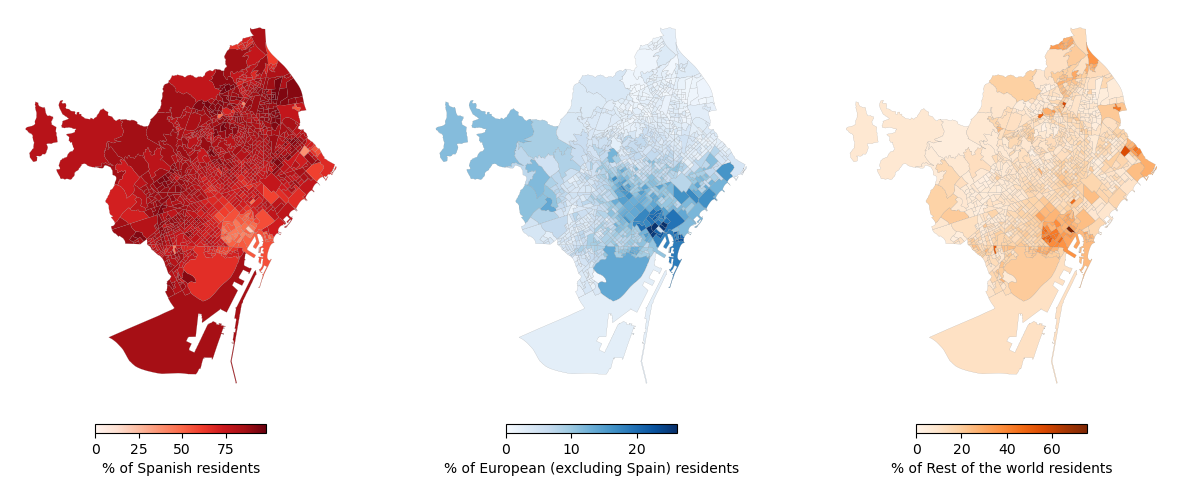

In [19]:
# creating a correspondence for colour maps
cmap_dict = {
    "Spanish": "Reds",
    "European (excluding Spain)": "Blues",
    "Rest of the world": "Oranges",
}

# an arranged grid of maps to show the spatial distribution of population of different nationalities
fig, axes = plt.subplots(1, 3, figsize=(15, 15))
nationalities = ["Spanish", "European (excluding Spain)", "Rest of the world"]
for ax, nationality in zip(axes.flatten(), nationalities):
    join_bcn_subset = join_bcn[join_bcn["Nationality"] == nationality]
    join_bcn_subset.plot(
        column="proportion",
        # a different colormap for each nationality
        cmap=cmap_dict[nationality],
        norm=colors.Normalize(vmin=0),
        edgecolor="gray",  # Borderline color
        linewidth=0.1,  # Borderline width,
        ax=ax,
        legend=True,
        legend_kwds={
            "orientation": "horizontal",
            "shrink": 0.5,
            "pad": 0.02,
            "label": f"% of {nationality} residents",
        },
    )
    # ax.set_title(f"% of {nationality} residents")
    ax.set_axis_off()





The mean disposable income per capita in 2022 was estimated at €23,000. As shown in the map below, there are clear spatial differences in income levels across Barcelona. Areas with disposable incomes up to 1.8 times the average are concentrated in the western parts of the city, such as *Sarria*, *Sant Gervasi*, and *Les Tres Torres*. In contrast, lower income levels are more prevalent in the southern and northern areas, where disposable income is around half the city average.

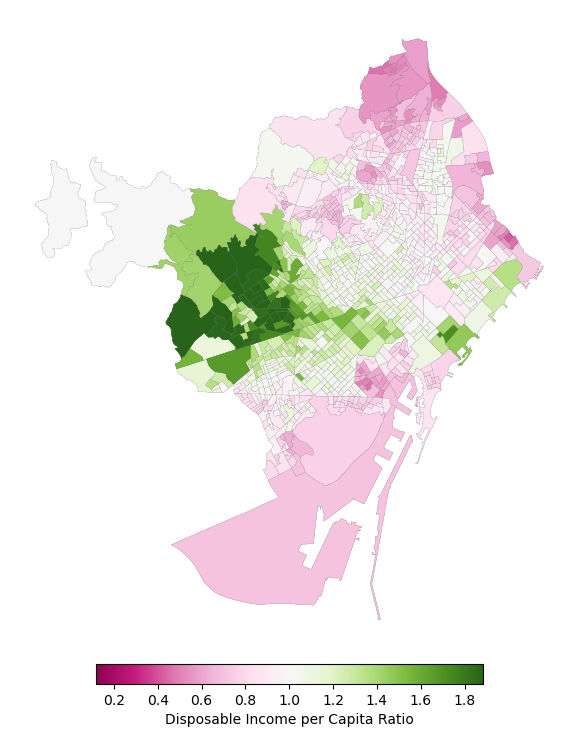

In [17]:
# Visualising the spatial distribution of disposable income ratio
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
join_bcn.plot(
    column="Income_Ratio",
    ax=ax,
    cmap="PiYG",
    edgecolor="gray",  # Borderline color
    linewidth=0.1,  # Borderline width,
    legend=True,
    norm=colors.CenteredNorm(vcenter=1),
    legend_kwds={"orientation": "horizontal",
                 "shrink": 0.5, "pad": 0.02, "label": "Disposable Income per Capita Ratio"},
)
ax.set_axis_off()

### 1.7 Spatial Autocorrelation Analysis

#### Concept and Methodology
Spatial autocorrelation measures the degree to which nearby areas have similar values for a given variable. 
We use Moran's I statistic and Local Indicators of Spatial Association (LISA) to:
1. Test whether spatial correlation exists (global Moran's I)
2. Identify local clusters and outliers (LISA)

In [ ]:
# Build spatial weights matrix using Queen contiguity
queen_weights = graph.Graph.build_contiguity(join_bcn, rook=False)

print("Spatial Weights Matrix (Queen Contiguity):")
print(f"Number of nodes: {queen_weights.n}")
print(f"Number of edges: {len(queen_weights.edges)}")
print(f"Average degree (neighbors per node): {2 * len(queen_weights.edges) / queen_weights.n:.2f}")

In [ ]:
from esda import Moran, lisa
from libpysal.weights import W

# Convert libpysal Graph to W object if needed
# Note: Adapt based on your libpysal version and available weights format

# Calculate Moran's I for disposable income
# Prepare data (remove NaN values)
valid_idx = join_bcn['Import_Euros'].notna()
income_values = join_bcn.loc[valid_idx, 'Import_Euros'].values

print(f"Computing Moran's I for Disposable Income (n={len(income_values)})")
print("This tests if high/low income areas cluster spatially...")

# Note: You may need to adjust the weights matrix format based on your libpysal version
# morans_income = Moran(income_values, weights_matrix)
# print(f"\nMoran's I Statistic: {morans_income.I:.4f}")
# print(f"P-value: {morans_income.p_sim:.6f}")

print("\n[Spatial autocorrelation analysis will be completed with appropriate weights matrix]")

## Part 2: Clustering and Classification

### 2.1 Neighbourhood Typology Creation

#### Objectives:
1. **Identify neighbourhood types** based on socio-economic indicators
2. **Characterize each cluster** (size, composition, economic profile)
3. **Spatial interpretation** of the typology across Barcelona
4. **Policy implications** - which areas need targeted interventions?

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings('ignore')

# Prepare data for clustering
# Select variables for clustering
clustering_vars = ['Import_Euros']  # Add more variables as needed
# For example: add nationality proportions if available

# Create feature matrix
X = join_bcn[clustering_vars].dropna().copy()
idx_valid = join_bcn[clustering_vars].notna().all(axis=1)

print(f"Number of census areas with complete data: {idx_valid.sum()}")
print(f"Variables used for clustering: {clustering_vars}")

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(join_bcn.loc[idx_valid, clustering_vars])

print(f"\nFeature matrix shape: {X_scaled.shape}")
print("Features standardized (mean=0, std=1)")

In [ ]:
# Determine optimal number of clusters using elbow method and silhouette score
from sklearn.metrics import silhouette_score

inertias = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))

# Plot optimization metrics
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method for Optimal k')
axes[0].grid(True, alpha=0.3)

axes[1].plot(K_range, silhouette_scores, 'ro-', linewidth=2, markersize=8)
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score by Number of Clusters')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Silhouette Scores:")
for k, score in zip(K_range, silhouette_scores):
    print(f"k={k}: {score:.4f}")

In [ ]:
# Apply K-means clustering with optimal k (adjust k based on results above)
optimal_k = 4  # Adjust based on elbow/silhouette analysis

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

# Add cluster assignments to main geodataframe
join_bcn.loc[idx_valid, 'cluster'] = clusters

print(f"Clustering completed with k={optimal_k}")
print(f"\nCluster distribution:")
print(join_bcn['cluster'].value_counts().sort_index())

### 2.2 Cluster Characterization

#### Question 1: Main Types of Neighbourhoods

In [ ]:
# Characterize each cluster
cluster_profiles = join_bcn.groupby('cluster')[clustering_vars].describe()
print("Cluster Profiles - Summary Statistics:")
print(cluster_profiles)

# Create more detailed cluster profiles
print("\n" + "="*80)
print("DETAILED CLUSTER PROFILES")
print("="*80)

for c in range(optimal_k):
    cluster_data = join_bcn[join_bcn['cluster'] == c][clustering_vars]
    print(f"\nCluster {c}:")
    print(f"  Number of areas: {len(cluster_data)}")
    print(f"  Mean income: €{cluster_data['Import_Euros'].mean():.2f}")
    print(f"  Std dev: €{cluster_data['Import_Euros'].std():.2f}")
    print(f"  Range: €{cluster_data['Import_Euros'].min():.2f} - €{cluster_data['Import_Euros'].max():.2f}")

#### Question 2: Characteristics that Delineate the Typology

In [ ]:
# Visualize cluster differences
fig, axes = plt.subplots(1, 1, figsize=(10, 6))

cluster_means = join_bcn.groupby('cluster')[clustering_vars].mean()
cluster_means.plot(kind='bar', ax=axes, width=0.7)
axes.set_xlabel('Cluster')
axes.set_ylabel('Mean Value (Standardized)')
axes.set_title('Mean Characteristics by Cluster')
axes.legend(title='Variables', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Boxplots for each variable by cluster
fig, axes = plt.subplots(1, len(clustering_vars), figsize=(12, 5))
if len(clustering_vars) == 1:
    axes = [axes]

for idx, var in enumerate(clustering_vars):
    join_bcn.boxplot(column=var, by='cluster', ax=axes[idx])
    axes[idx].set_title(f'{var} by Cluster')
    axes[idx].set_xlabel('Cluster')
    plt.suptitle('')

plt.tight_layout()
plt.show()

### 2.3 Spatial Distribution of Clusters

#### Question 3: Policy Targeting and Question 4: City Partitioning

In [ ]:
# Choropleth map of clusters
fig, ax = plt.subplots(figsize=(12, 10))
join_bcn.plot(column='cluster', cmap='tab10', ax=ax, legend=True, 
              edgecolor='k', linewidth=0.5, categorical=True)
ax.set_title('Neighbourhood Typology: Spatial Distribution of Clusters', 
             fontsize=14, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.show()

# Interactive map for cluster exploration
cluster_map = join_bcn.explore(column='cluster', cmap='tab10', legend=True, 
                               categorical=True, tooltip=['code_sec', 'cluster', 'Import_Euros'])
cluster_map

In [ ]:
# Analysis of spatial concentration
print("SPATIAL CONCENTRATION ANALYSIS")
print("="*80)
print("\nHow is Barcelona partitioned by the data?")
print(f"\nTotal census areas: {len(join_bcn)}")
print(f"Areas with data: {join_bcn['cluster'].notna().sum()}\n")

# Cluster distribution by area
for c in range(optimal_k):
    cluster_areas = join_bcn[join_bcn['cluster'] == c]
    pct = len(cluster_areas) / len(join_bcn) * 100
    print(f"Cluster {c}: {len(cluster_areas):3d} areas ({pct:5.1f}%)")

print("\n" + "="*80)
print("Policy Targeting Strategy:")
print("="*80)
print("""
Based on the clustering results:

1. IDENTIFY HIGH-NEED CLUSTERS:
   - Focus on clusters with lowest income levels
   - Examine concentration patterns
   
2. INTERVENTION PRIORITIES:
   - Cluster characteristics suggest different policy approaches
   - Consider spatial concentration vs. dispersal
   
3. TARGETING EFFICIENCY:
   - Are vulnerable areas clustered (efficient targeting) or dispersed?
   - What districts/neighborhoods are most affected?
""")

## Part 3: Optional Extensions

### 3.1 Alternative: Airbnb Analysis (Option 2 or 3)

**Note:** If you choose to pursue the Airbnb analysis instead of clustering, uncomment and complete the cells below:

In [ ]:
"""
# AIRBNB ANALYSIS (Optional Extension)
# Uncomment and complete the following sections if pursuing Airbnb option

# 3.1.1 Load Airbnb Data from Inside Airbnb
# url_airbnb = 'http://data.insideairbnb.com/spain/catalonia/barcelona/2024-XX-XX/visualisations/listings.csv'
# airbnb_data = pd.read_csv(url_airbnb)

# 3.1.2 Georeference Airbnb Listings
# gdf_airbnb = gpd.GeoDataFrame(
#     airbnb_data, 
#     geometry=gpd.points_from_xy(airbnb_data.longitude, airbnb_data.latitude),
#     crs='EPSG:4326'
# )

# 3.1.3 Join with Census Areas (Spatial Join)
# gdf_airbnb_bcn = gpd.sjoin(gdf_airbnb, join_bcn, how='left', predicate='within')

# 3.1.4 Calculate Airbnb Density by Census Area
# airbnb_density = gdf_airbnb_bcn.groupby('code_sec').size().reset_index(name='airbnb_count')
# join_bcn = join_bcn.merge(airbnb_density, on='code_sec', how='left')

# Then visualize distribution, assess equality, create regionalization, 
# and perform regression analysis linking socio-economic factors to Airbnb presence
"""

print("Airbnb analysis template prepared (commented out)")
print("Uncomment and adapt as needed for your analysis")

## Conclusions and Key Findings

### Summary of Analysis:
1. **Spatial Distribution Patterns**: [Your findings about how variables are distributed across Barcelona]
2. **Spatial Autocorrelation**: [Your interpretation of clustering patterns]
3. **Neighbourhood Typology**: [Main types identified and their characteristics]
4. **Policy Implications**: [Recommendations for urban policy makers]

### Reflections:
- What surprised you about Barcelona's socio-economic structure?
- How would you use these insights if you were a city planner?
- Are there other variables you would like to explore?


[<sup id="fn1">1</sup>](#fn1-back) footnote and tooltip 1

[<sup id="fn2">2</sup>](#fn2-back) footnote 2